In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# !pip install torchmetrics
import torchmetrics

In [18]:
from IPython.display import display, Markdown

- [Tutoriais PyTorch](https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)

- [Tutorial ConvNet 1](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html)

- [Tutorial ConvNet 2](https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch/)

--- 

# Parte A

---

### **01 ) - Análise Exploratória de Dados**

---


Dataset:
- ...

DataLoader
- ...

batch_size
- ...

shuffle
- ...

transforms.ToTensor().
- ...

---

##### ***Importando o dataset***


In [ ]:
batch_size = 60

train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

##### ***Quantidade de exemplos de treinamento***


In [40]:
len_test_samples = train_dataset.data.shape[0]

text = f"##### - Quantidade de amostras de treinamento: **{len_test_samples}**"

display(Markdown(text))

##### - Quantidade de amostras de treinamento: **60000**

##### ***Quantidade de exemplos de teste***

In [39]:
len_test_samples = test_dataset.data.shape[0]

text = f"##### - Quantidade de amostras de teste: **{len_test_samples}**"

display(Markdown(text))

##### - Quantidade de amostras de teste: **10000**

##### ***Dimensão das imagens***

In [38]:
imagem, rotulo = train_dataset[0]

text = f"##### - As imagens tem: **{imagem.shape[1]}** dimenções"

display(Markdown(text))

##### - As imagens tem: **28** dimenções

##### ***Número de classes***

In [34]:
text = f"##### - Classes do dataset MNIST:"

display(Markdown(text))

train_dataset.classes

##### - Classes do dataset MNIST:

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

##### ***Tamanho do batch utilizado***

In [37]:
text = f"##### - Tamanho do batch do dataset: **{train_loader.batch_size}**"

display(Markdown(text))

##### - Tamanho do batch do dataset: **60**

##### ***Exemplos de imagens***

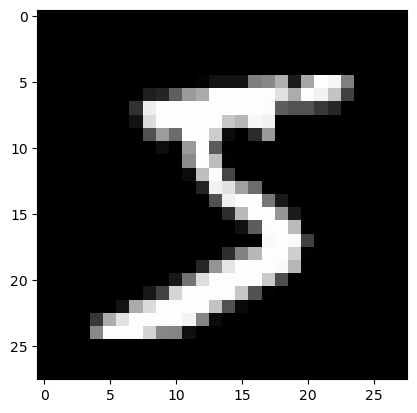

In [13]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_dataset)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))


---

### **02 ) - Implementação**

---

##### ***Arquitetura***

In [43]:
class CNN(nn.Module):
   def __init__(self, in_channels=1, num_classes=10):

       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

In [ ]:
def forward(self, x):

    x = F.relu(self.conv1(x))  
    x = self.pool(x)           
    x = F.relu(self.conv2(x))  
    x = self.pool(x)           
    x = x.reshape(x.shape[0], -1)  
    x = self.fc1(x)            
    return x

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels=1, num_classes=10).to(device)

##### ***Total de parâmetros***

---

### **03 ) - Treinamento**

---